In [78]:
import os
import numpy as np
import subprocess as proc
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go

executable_path = os.path.join("..", "..", "cmake-build-release", "src", "04")
#seeds_path = os.path.join("..", "ariel_rng")
#seeds_args = ["--primes="+os.path.join(seeds_path, "Primes"), "--seeds=" + os.path.join(seeds_path, "seed.in")]
input_arg = f"--input={os.path.abspath('./sim_conf/input.solid')}"
data_root = os.path.join(".", "simulations/")
os.makedirs(data_root, exist_ok = True)

In [79]:
ex = "04_1"
data_1 = data_root
proc.run([os.path.join(executable_path, ex), f"-o={data_root}", input_arg])

Classic Lennard-Jones fluid        
MD(NVE) / MC(NVT) simulation       

Interatomic potential v(r) = 4 * [(1/r)^12 - (1/r)^6]

Boltzmann weight exp(- beta * sum_{i<j} v(r_ij) ), beta = 1/T 

The program uses Lennard-Jones units 
Temperature = 0.8
Number of particles = 108
Density of particles = 1.1
Volume of the simulation box = 98.1818
Edge of the simulation box = 4.61329
Cutoff of the interatomic potential = 2.2

The program perform Metropolis moves with uniform translations
Moves parameter = 0.0005
Number of blocks = 20
Number of steps in one block = 2000

Read initial configuration

Prepare velocities with center of mass velocity equal to zero 
velocity scale factor: 1.01934

Initial potential energy = -7.85046
Initial temperature      = 0.8
Initial kinetic energy   = 1.2
Initial total energy     = -6.65046
Initial pressure         = 0.0291096
Print final configuration to file config.out



CompletedProcess(args=['../../cmake-build-release/src/04/04_1', '-o=./simulations/', '--input=/Users/davidenicoli/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Uni/Workspace/LabSiNum/esercizi_lsn/src/04/sim_conf/input.solid'], returncode=0)

In [80]:
data = [pd.read_fwf(os.path.join(data_root, f"output_{var}.dat"),
                       header=None,
                       names=["n_block", "block_avg", "prog_avg", "error"]) for var in ["ekin", "epot", "etot", "pres", "temp"]]

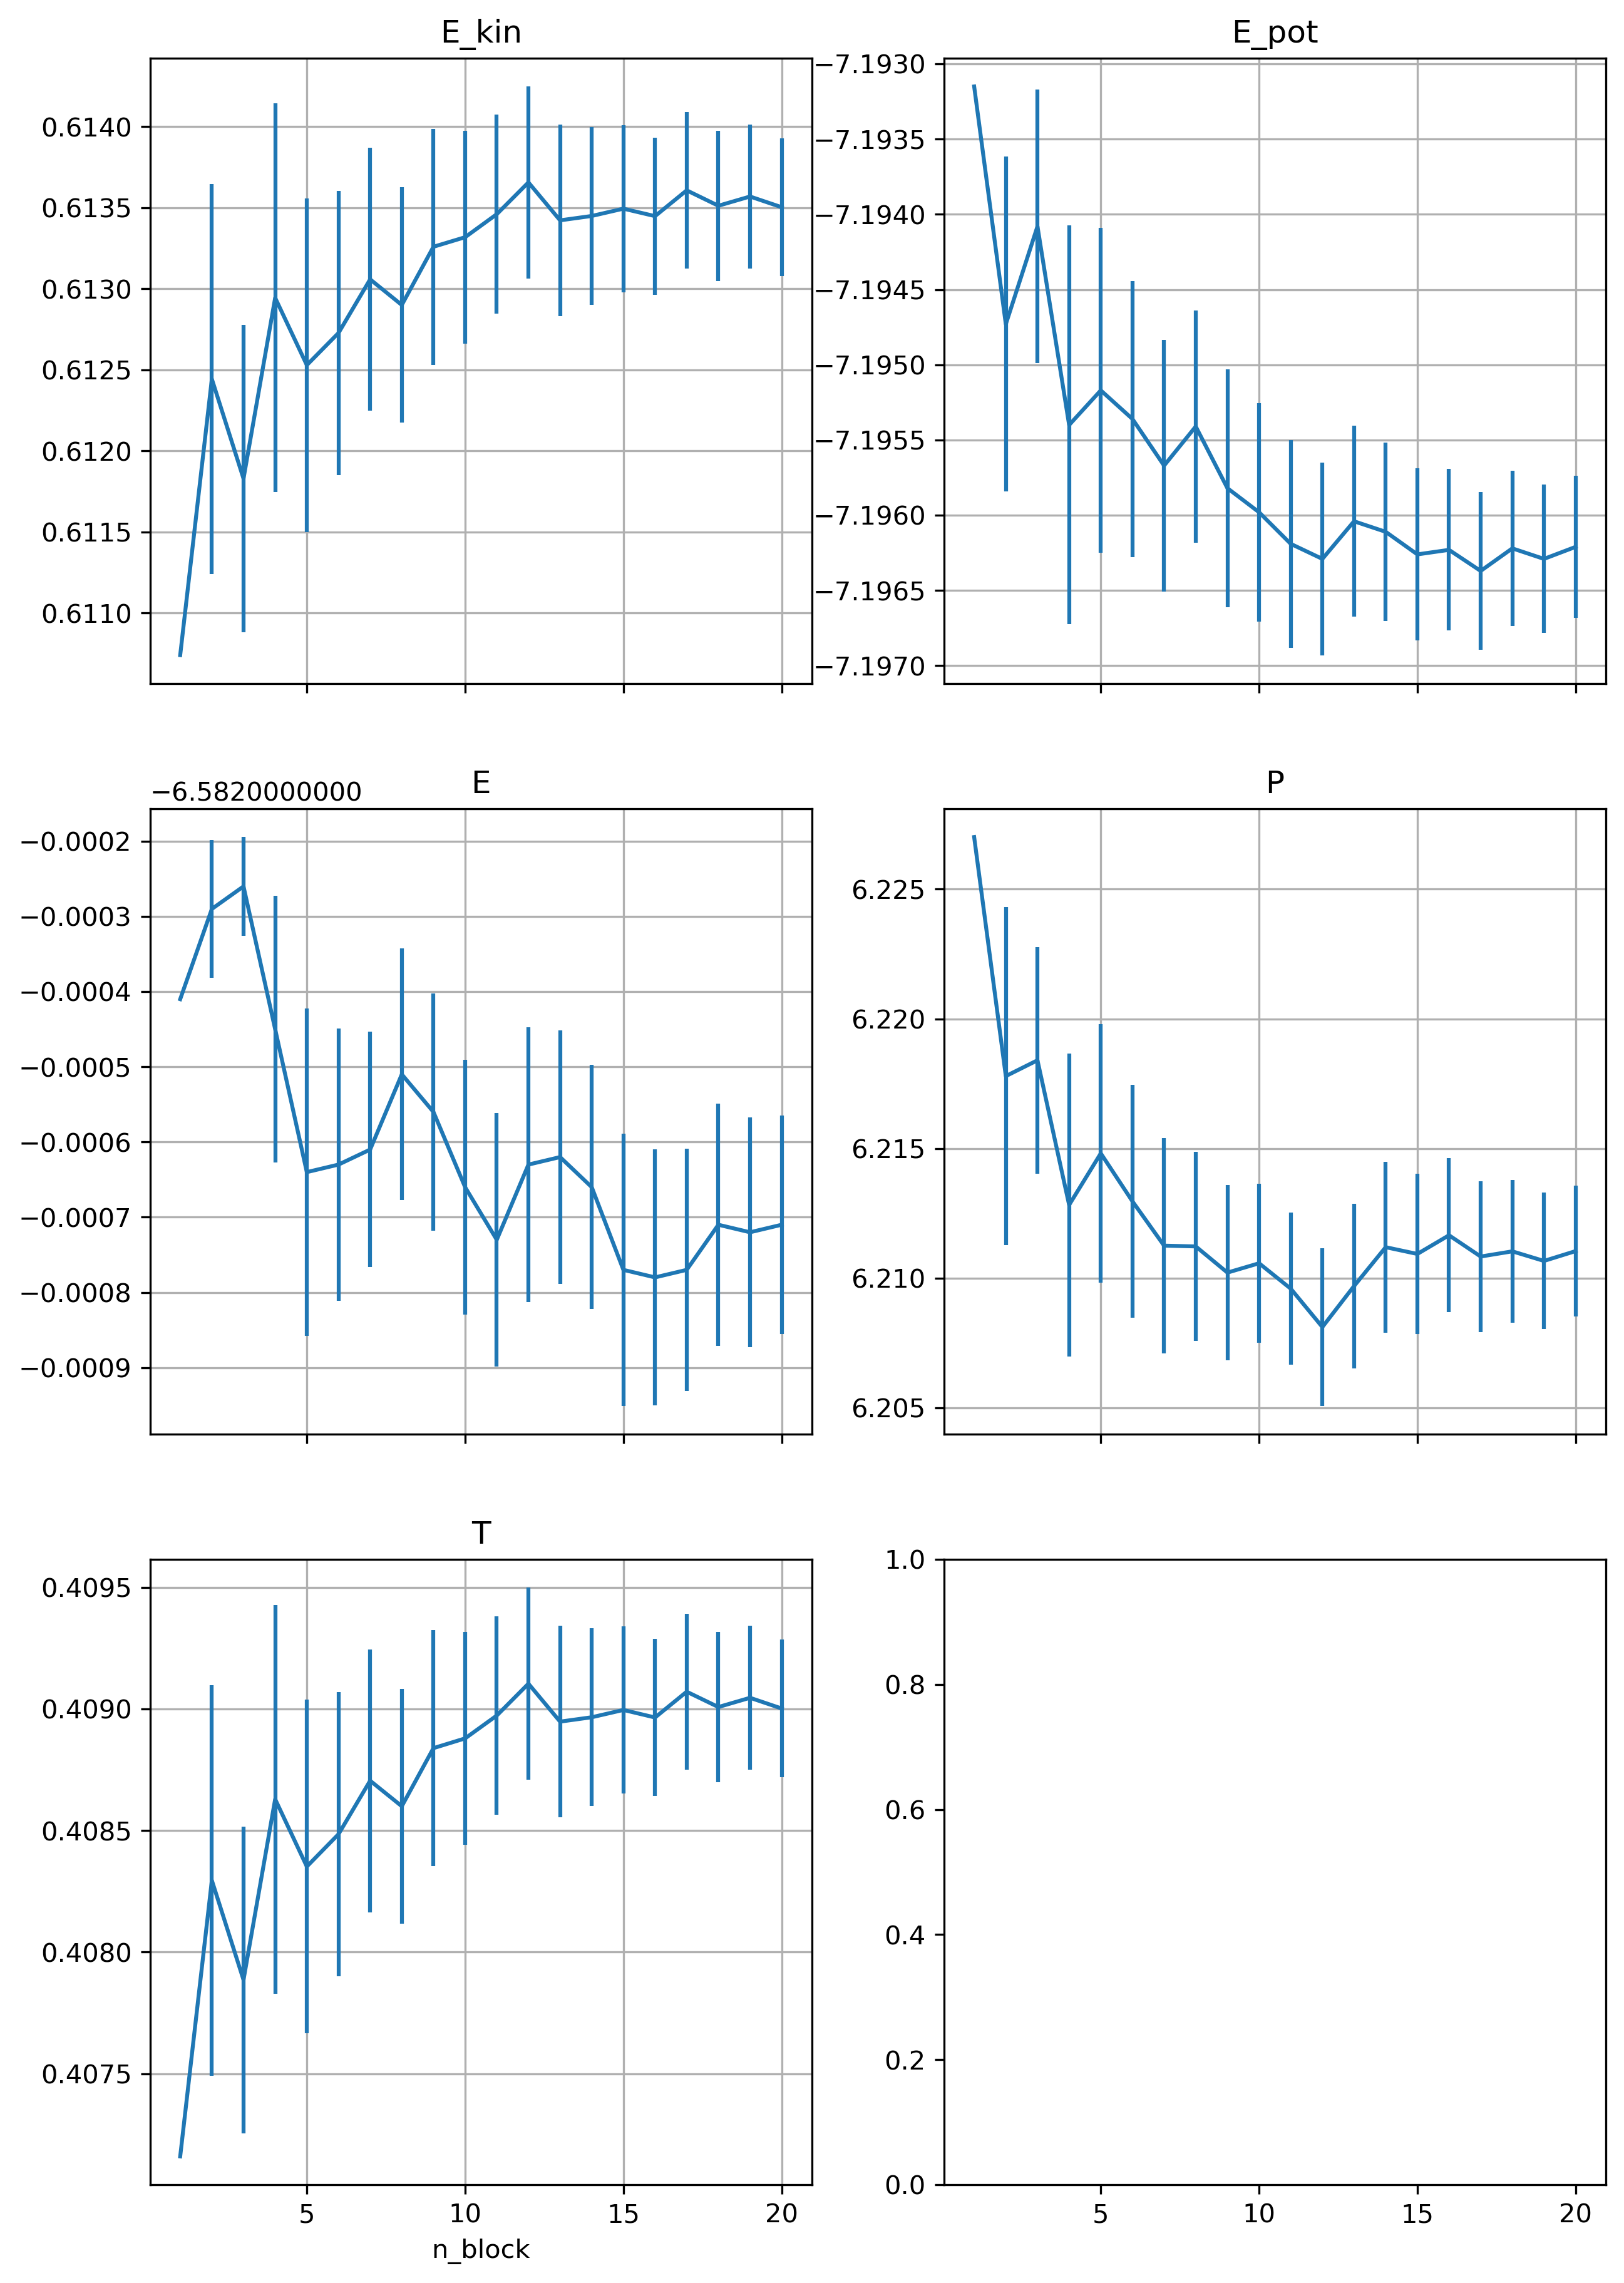

In [81]:
fig, axes = plt.subplots(3, 2, dpi=300, sharex=True, figsize=(10, 15))
for ax, name, d in zip(axes.flatten(), ["E_kin", "E_pot", "E", "P", "T"], data):
    d.plot("n_block", "prog_avg", yerr="error", ax=ax, title=name, legend=False)
    ax.grid()

In [68]:
data[3]

,n_block,block_avg,prog_avg,error
0,1,3.20802,3.20802,0.000000
1,2,3.33198,3.27000,0.043825
2,3,3.46160,3.33387,0.059774
3,4,3.55948,3.39027,0.066301
4,5,3.69843,3.45190,0.076499
5,6,3.82521,3.51412,0.085381
6,7,3.94802,3.57611,0.093000
7,8,4.08131,3.63926,0.100556
8,9,4.23566,3.70552,0.109053
9,10,4.42137,3.77711,0.119352


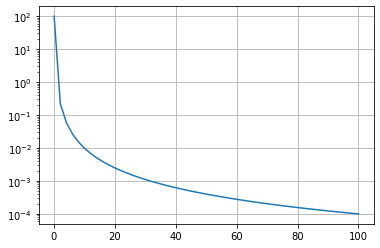

In [87]:
xs = np.linspace(0.1,100)
ys = np.power(xs, -2)
plt.plot(xs, ys)
plt.yscale("log")
plt.grid()